In [429]:
import os

print(os.listdir("./data_madrid"))

['dataset-copy.csv', 'dataset.csv']


In [430]:
import os
import pandas as pd

data_madrid = pd.read_csv(r"data_madrid/dataset-copy.csv")

<class 'pandas.DataFrame'>
RangeIndex: 11826 entries, 0 to 11825
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   provincia       11826 non-null  str    
 1   zona            11826 non-null  str    
 2   titulo          11826 non-null  str    
 3   PrecioActual    11826 non-null  int64  
 4   PrecioAnterior  11826 non-null  int64  
 5   metros          11826 non-null  int64  
 6   habitaciones    11460 non-null  float64
 7   ascensor        11033 non-null  str    
 8   localizacion    10730 non-null  str    
 9   planta          10601 non-null  str    
 10  baños           11826 non-null  int64  
 11  tags            11664 non-null  str    
 12  descripcion     11761 non-null  str    
 13  Enlace          11826 non-null  str    
dtypes: float64(1), int64(4), str(9)
memory usage: 1.3 MB
None


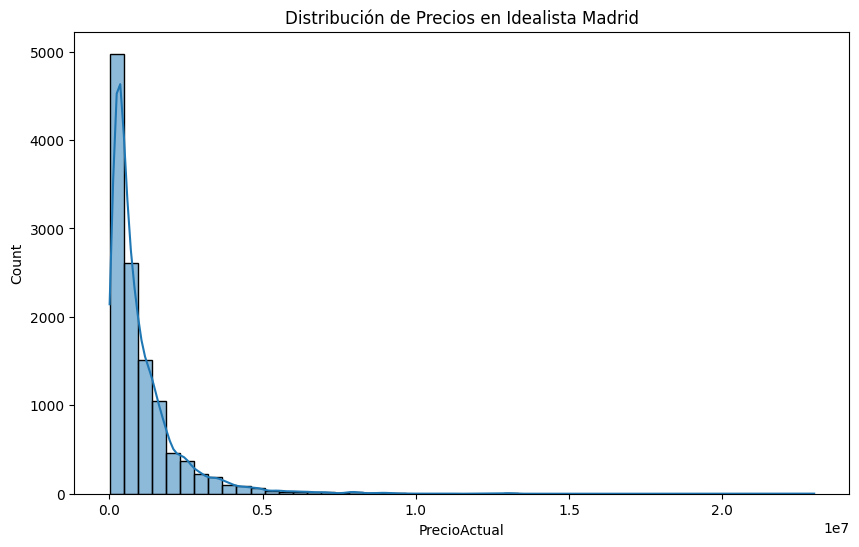

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("./data_madrid/dataset-copy.csv")

print(df.info())

plt.figure(figsize=(10, 6))
sns.histplot(df['PrecioActual'], bins=50, kde=True)
plt.title('Distribución de Precios en Idealista Madrid')
plt.show()


In [432]:
import sys
print(sys.executable)


/Users/rup/Documents/SaturdayAI/saturdayTesting/.venv/bin/python3


In [445]:
import os
from IPython.display import display
print(os.getcwd())
print(os.listdir()) 

for root, dirs, files in os.walk("."):
    if "dataset-copy.csv" in files:
        file_path = os.path.join(root, "dataset.csv")
        print(f"Found it! Loading from: {file_path}")
        df = pd.read_csv(file_path)
        break
else:
    print("File not found in current directory or subdirectories.")

if 'df' in locals():
    pd.options.display.max_columns = None
    display(df.head())

/Users/rup/Documents/Factoria F5/ia-regression-project-team-2
['ia_regression_project_team_2.egg-info', 'data_madrid', 'uv.lock', 'pyproject.toml', 'README.md', '.gitignore', '.env', '.venv', '.python-version', '.git', 'main.py', 'eda-dataset.ipynb']
Found it! Loading from: ./data_madrid/dataset.csv


,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
0,madrid,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,0,69,2.0,S,EXTERIOR,5ª,1,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,https://www.idealista.com/inmueble/106956987/
1,madrid,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,159000,91,3.0,N,EXTERIOR,1ª,0,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,https://www.idealista.com/inmueble/106906044/
2,madrid,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,0,36,1.0,S,NaN,2ª,0,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...,https://www.idealista.com/inmueble/107306175/
3,madrid,usera,"Piso en calle de Ferroviarios, Almendrales, Ma...",195000,0,58,1.0,S,INTERIOR,BAJO,0,"VIVIENDA,HOGAR,FUNCIONAL","Esta acogedora vivienda, ubicada en una planta...",https://www.idealista.com/inmueble/106325171/
4,madrid,tetuan,"Dúplex en Bellas Vistas, Madrid",715000,750000,140,3.0,S,EXTERIOR,2ª,0,"TERRAZA,EXCLUSIVA,MODERNO","Maravilloso ATICO de reciente construcción, co...",https://www.idealista.com/inmueble/106627265/


In [2]:
columns_to_use = ["zona", "metros", "habitaciones", "ascensor", "localizacion", "planta", "PrecioActual"]
df = df[columns_to_use]

display(df.head())

NameError: name 'df' is not defined

In [435]:
print(df.dtypes)

print(df.isnull().sum())

zona                str
metros            int64
habitaciones    float64
ascensor            str
localizacion        str
planta              str
PrecioActual      int64
dtype: object
zona               0
metros             0
habitaciones     366
ascensor         793
localizacion    1096
planta          1225
PrecioActual       0
dtype: int64


In [436]:
display(df.describe())

print(df['zona'].value_counts())
print(df['ascensor'].value_counts())


,metros,habitaciones,PrecioActual
count,11826.000000,11460.000000,1.182600e+04
mean,153.790039,2.847731,1.030501e+06
std,766.217750,1.432402,1.237718e+06
min,11.000000,1.000000,1.200000e+04
25%,68.000000,2.000000,2.890000e+05
50%,103.000000,3.000000,6.200000e+05
75%,160.000000,3.000000,1.329000e+06
max,75000.000000,20.000000,2.300000e+07


zona
barrio-de-salamanca    2018
centro                 1890
chamberi                796
chamartin               706
tetuan                  596
moncloa                 580
carabanchel             567
ciudad-lineal           537
puente-de-vallecas      526
retiro                  508
hortaleza               444
fuencarral              391
arganzuela              386
san-blas                335
latina                  331
villaverde              314
usera                   302
villa-de-vallecas       212
vicalvaro               193
moratalaz                97
barajas                  97
Name: count, dtype: int64
ascensor
S    8419
N    2614
Name: count, dtype: int64


In [437]:
missing_pct = df.isnull().mean() * 100

columns_over_10pct = missing_pct[missing_pct > 10]
print(columns_over_10pct)

planta    10.358532
dtype: float64


In [438]:
df['planta'] = df['planta'].fillna(df['planta'].median())

print(df['planta'].isnull().sum())

TypeError: Cannot perform reduction 'median' with string dtype

In [ ]:
# print(df['planta'].dtype)
# print(df['planta'].unique())


In [443]:
# Mapping for special floor values
floor_mapping = {
    'BAJO': 0,
    'SÓTANO': -1,
    'ENTREPLANTA': 0.5  # or another value you prefer
}

# Remove 'ª' and convert numeric floors to int
def convert_floor(x):
    if pd.isnull(x):
        return None
    x = str(x).strip()
    if x in floor_mapping:
        return floor_mapping[x]
    try:
        return int(x.replace('ª',''))
    except:
        return None

df['planta_num'] = df['planta'].apply(convert_floor)

# Fill missing values with median
df['planta_num'] = df['planta_num'].fillna(df['planta_num'].median())

# Verify
print(df[['planta','planta_num']].head(15))


   planta  planta_num
0      5ª         5.0
1      1ª         1.0
2      2ª         2.0
3    BAJO         0.0
4      2ª         2.0
5      3ª         3.0
6      6ª         6.0
7      1ª         1.0
8     NaN         2.0
9      3ª         3.0
10     1ª         1.0
11    NaN         2.0
12     2ª         2.0
13     2ª         2.0
14     1ª         1.0


In [12]:

cols = ["zona", "metros", "habitaciones", "ascensor", "localizacion", "planta", "PrecioActual"]
df = df[cols] 


floor_mapping = {'BAJO': 0, 'SÓTANO': -1, 'ENTREPLANTA': 0}

def convert_floor(x):
    if pd.isnull(x): return None
    x = str(x).strip().upper()
    if x in floor_mapping: return floor_mapping[x]
    try:
        return int(x.replace('ª',''))
    except:
        return None

df['planta_num'] = df['planta'].apply(convert_floor)

mediana = df['planta_num'].median()
df['planta_num'] = df['planta_num'].fillna(mediana).astype(int)

df['habitaciones'] = df['habitaciones'].fillna(0).astype(int)

display(df.head())


,zona,metros,habitaciones,ascensor,localizacion,planta,PrecioActual,planta_num
0,ciudad-lineal,69,2,S,EXTERIOR,5ª,355000,5
1,carabanchel,91,3,N,EXTERIOR,1ª,149000,1
2,centro,36,1,S,NaN,2ª,195000,2
3,usera,58,1,S,INTERIOR,BAJO,195000,0
4,tetuan,140,3,S,EXTERIOR,2ª,715000,2


In [7]:
columns_to_use = ["zona", "metros", "habitaciones", "ascensor", "localizacion", "planta_num", "PrecioActual"]
df = df[columns_to_use]

display(df.head(20))

KeyError: "['planta_num'] not in index"

In [18]:
df['ascensor'] = df['ascensor'].replace({'s': 1, 'n': 0, 'S': 1, 'N': 0}).fillna(0).astype(int)


In [10]:
columns_to_use = ["zona", "metros", "habitaciones", "ascensor", "localizacion", "planta_num", "PrecioActual"]
df = df[columns_to_use]

display(df.head())

KeyError: "['planta_num'] not in index"

In [ ]:
df['habitaciones'] = df['habitaciones'].astype('Int64')



In [19]:
columns_to_use = ["zona", "metros", "habitaciones", "ascensor", "localizacion", "planta_num", "PrecioActual"]
df = df[columns_to_use]

display(df.head(10))

,zona,metros,habitaciones,ascensor,localizacion,planta_num,PrecioActual
0,ciudad-lineal,69,2,1,1,5,355000
1,carabanchel,91,3,0,1,1,149000
2,centro,36,1,1,0,2,195000
3,usera,58,1,1,0,0,195000
4,tetuan,140,3,1,1,2,715000
5,arganzuela,135,3,1,1,3,1257000
6,barrio-de-salamanca,81,1,1,0,6,830000
7,puente-de-vallecas,43,1,0,1,1,70000
8,moncloa,500,6,0,0,2,2150000
9,chamberi,139,2,1,1,3,1847800


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
print("Columnas detectadas:", df.columns.tolist())

Columnas detectadas: ['zona', 'metros', 'habitaciones', 'ascensor', 'localizacion', 'planta_num', 'PrecioActual']


In [ ]:
df['localizacion'] = (df['localizacion'] == 'EXTERIOR').astype(int)

conteos = df['localizacion'].value_counts()

print(f"Exteriores (1): {conteos.get(1, 0)}")
print(f"Interiores (0): {conteos.get(0, 0)}")

display(df[df['localizacion'] == 1].head(10))

Exteriores (1): 9087
Interiores (0): 2739


,zona,metros,habitaciones,ascensor,localizacion,planta,PrecioActual,planta_num
0,ciudad-lineal,69,2,S,1,5ª,355000,5
1,carabanchel,91,3,N,1,1ª,149000,1
4,tetuan,140,3,S,1,2ª,715000,2
5,arganzuela,135,3,S,1,3ª,1257000,3
7,puente-de-vallecas,43,1,N,1,1ª,70000,1
9,chamberi,139,2,S,1,3ª,1847800,3
10,arganzuela,90,3,S,1,1ª,509000,1
12,usera,80,2,S,1,2ª,275000,2
14,barrio-de-salamanca,67,1,S,1,1ª,380000,1
15,puente-de-vallecas,76,3,N,1,2ª,220000,2


In [ ]:
# print(df['localizacion'].value_counts())
# print(df['ascensor'].value_counts())
# print(df['planta_num'].value_counts())
# print(df['metros'].value_counts())
# print(df['habitaciones'].value_counts())
# print(df['zona'].value_counts())
# print(df['PrecioActual'].value_counts())


In [16]:

display(df.head(30))

,zona,metros,habitaciones,ascensor,localizacion,planta,PrecioActual,planta_num
0,ciudad-lineal,69,2,S,1,5ª,355000,5
1,carabanchel,91,3,N,1,1ª,149000,1
2,centro,36,1,S,0,2ª,195000,2
3,usera,58,1,S,0,BAJO,195000,0
4,tetuan,140,3,S,1,2ª,715000,2
5,arganzuela,135,3,S,1,3ª,1257000,3
6,barrio-de-salamanca,81,1,S,0,6ª,830000,6
7,puente-de-vallecas,43,1,N,1,1ª,70000,1
8,moncloa,500,6,NaN,0,NaN,2150000,2
9,chamberi,139,2,S,1,3ª,1847800,3


In [ ]:
# df['localizacion'] = (df['localizacion'] == 'EXTERIOR').astype(int)


# display(df[df['localizacion'] == 1].head(10))

In [ ]:
# print("Valores reales en la columna:", df['localizacion'].unique())

Valores reales en la columna: [0]


In [14]:

display(df.head(10))

,zona,metros,habitaciones,ascensor,localizacion,planta,PrecioActual,planta_num
0,ciudad-lineal,69,2,S,EXTERIOR,5ª,355000,5
1,carabanchel,91,3,N,EXTERIOR,1ª,149000,1
2,centro,36,1,S,NaN,2ª,195000,2
3,usera,58,1,S,INTERIOR,BAJO,195000,0
4,tetuan,140,3,S,EXTERIOR,2ª,715000,2
5,arganzuela,135,3,S,EXTERIOR,3ª,1257000,3
6,barrio-de-salamanca,81,1,S,INTERIOR,6ª,830000,6
7,puente-de-vallecas,43,1,N,EXTERIOR,1ª,70000,1
8,moncloa,500,6,NaN,NaN,NaN,2150000,2
9,chamberi,139,2,S,EXTERIOR,3ª,1847800,3


In [ ]:
valores_unicos = df['planta_num'].unique()
print(valores_unicos)

[ 5  1  2  0  3  6  4 16 13  9  7 10  8 14 11 12 -1 15 17 20 -2 27 22 21
 18]


In [ ]:
zonas = sorted(df['zona'].unique())
print(df['zona'].value_counts())
print(zonas)

zona
barrio-de-salamanca    2018
centro                 1890
chamberi                796
chamartin               706
tetuan                  596
moncloa                 580
carabanchel             567
ciudad-lineal           537
puente-de-vallecas      526
retiro                  508
hortaleza               444
fuencarral              391
arganzuela              386
san-blas                335
latina                  331
villaverde              314
usera                   302
villa-de-vallecas       212
vicalvaro               193
moratalaz                97
barajas                  97
Name: count, dtype: int64
['arganzuela', 'barajas', 'barrio-de-salamanca', 'carabanchel', 'centro', 'chamartin', 'chamberi', 'ciudad-lineal', 'fuencarral', 'hortaleza', 'latina', 'moncloa', 'moratalaz', 'puente-de-vallecas', 'retiro', 'san-blas', 'tetuan', 'usera', 'vicalvaro', 'villa-de-vallecas', 'villaverde']


In [ ]:
import pandas as pd

df_corr = df.copy()

zona_map = df_corr.groupby('zona')['PrecioActual'].mean()
df_corr['zona_impacto'] = df_corr['zona'].map(zona_map)

columnas_finales = ['zona_impacto', 'metros', 'habitaciones', 'ascensor', 'localizacion', 'planta_num', 'PrecioActual']

correlacion = df_corr[columnas_finales].corr()['PrecioActual'].sort_values(ascending=False)

print(correlacion)




PrecioActual    1.000000
habitaciones    0.509278
zona_impacto    0.508667
planta_num      0.164917
ascensor        0.154931
metros          0.130661
localizacion         NaN
Name: PrecioActual, dtype: float64


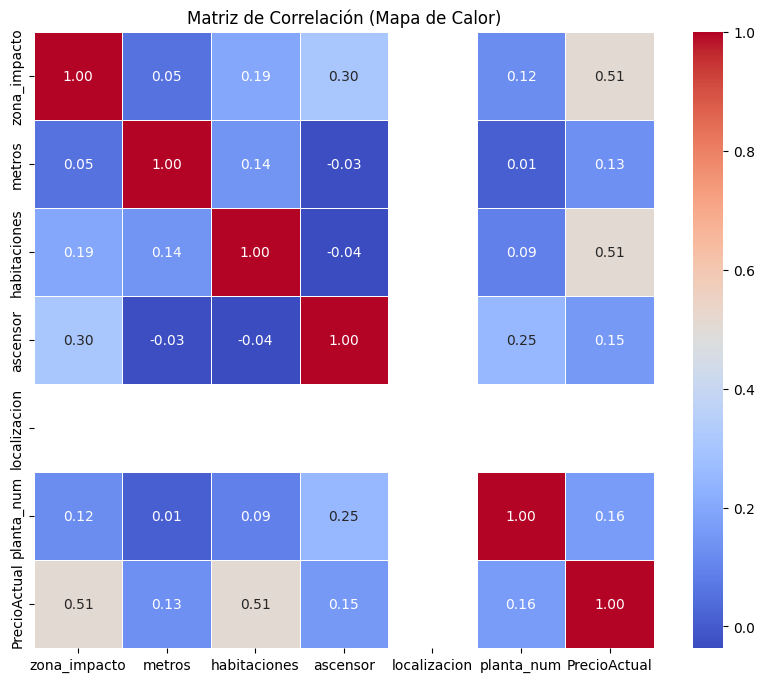

In [ ]:

plt.figure(figsize=(10, 8))

sns.heatmap(matriz_completa, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Matriz de Correlación (Mapa de Calor)")
plt.show()
